# 모델별 결과 및 비교이미지

## 1. 모델별 성능 비교

* Faster R-CNN: test 데이터셋에서 종합 mAP@0.50 0.7766, 종합 Recall 0.5277을 기록하여 mAP 기준에서 가장 안정적인 성능을 보였다. 클래스별로는 Person, Helmet, Vest 클래스에서 비교적 높은 성능을 보였고, No-Helmet 클래스는 상대적으로 낮은 성능을 보였다.

* YOLOv8: Confidence 0.5, IoU 0.6 기준으로 평가하였다. 클래스별 F1-Score는 Helmet 79.8%, Person 79.5%, Vest 68.2%, No-Vest 50.0%, No-Helmet 14.8%로 나타났다. YOLOv8은 사람과 헬멧 객체는 비교적 잘 탐지했지만, No-Helmet 클래스는 가장 낮은 성능을 보였다.

* Custom Model: 종합 mAP@0.50 0.1111, 종합 Recall 0.0645를 기록하였다. 일부 객체를 탐지하는 것은 가능했지만, Faster R-CNN과 YOLOv8에 비해 미탐지와 오탐지가 많이 발생하였다.

## 2. 탐지 결과 해석

* Faster R-CNN과 YOLOv8: 탐지 이미지에서 사람, 헬멧, 조끼 등 주요 객체를 어느 정도 탐지하는 모습을 보였다. 그러나 YOLOv8의 시각화 결과에서는 헬멧 착용자를 No-Helmet으로 예측하거나, 조끼 착용자를 No-Vest로 예측하는 클래스 혼동이 확인되었다. 이는 정량 평가에서 No-Helmet 클래스의 Recall 8.3%, F1-Score 14.8%로 낮게 나타난 결과와 연결된다. 즉, 모델이 객체 위치를 찾는 것은 어느 정도 가능했지만, 안전장비 착용 여부를 세밀하게 구분하는 데에는 한계가 있었다.

* Custom Model: 직접 구현한 모델이라는 점에서 의미가 있었지만, 사전 학습 모델에 비해 탐지 성능이 낮았다. 특히 No-Helmet 클래스는 mAP와 Recall이 모두 0.0000으로 나타나 해당 클래스를 거의 탐지하지 못하였다.



**YOLOv8 평가 결과 및 탐지 이미지**

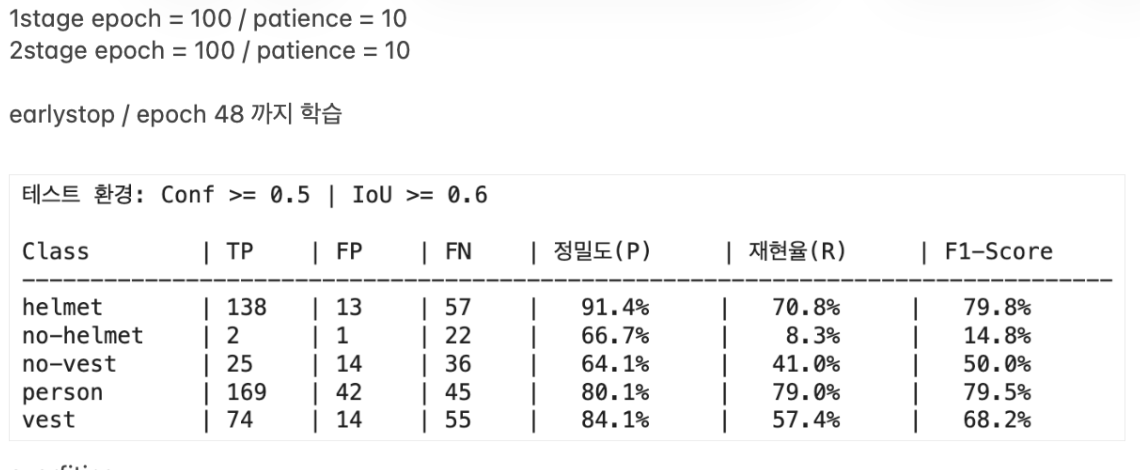

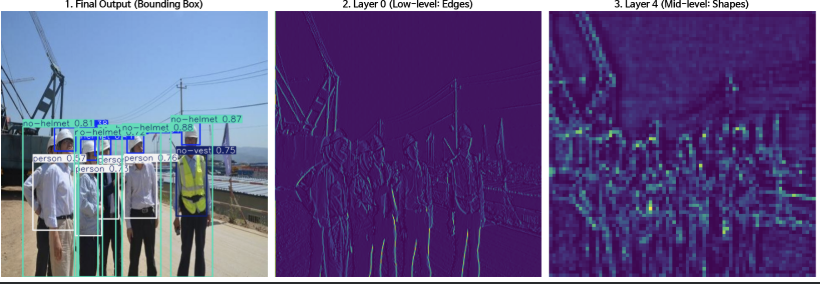

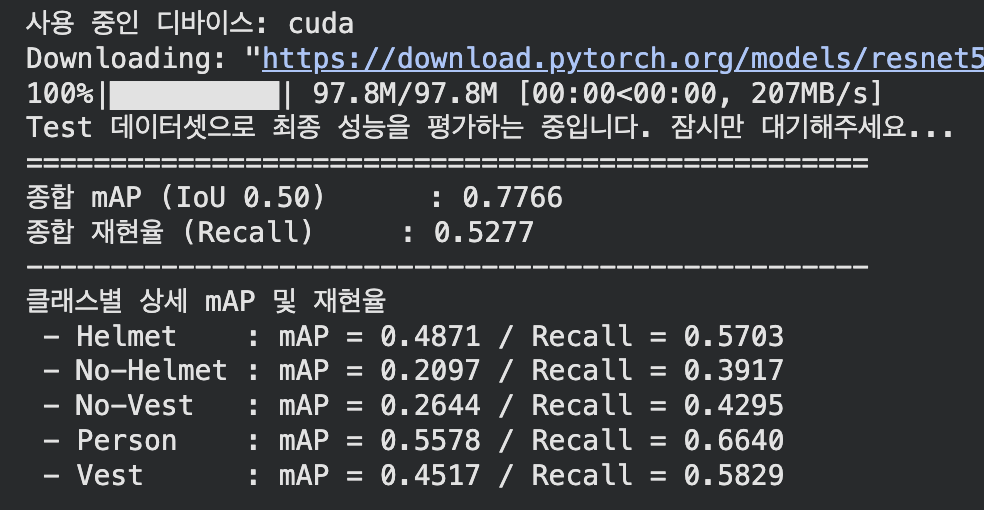

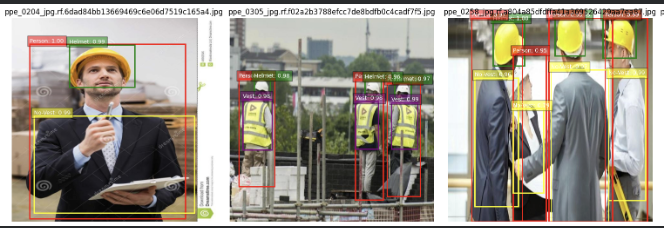

**Custom Model 평가 결과 및 탐지 이미지**

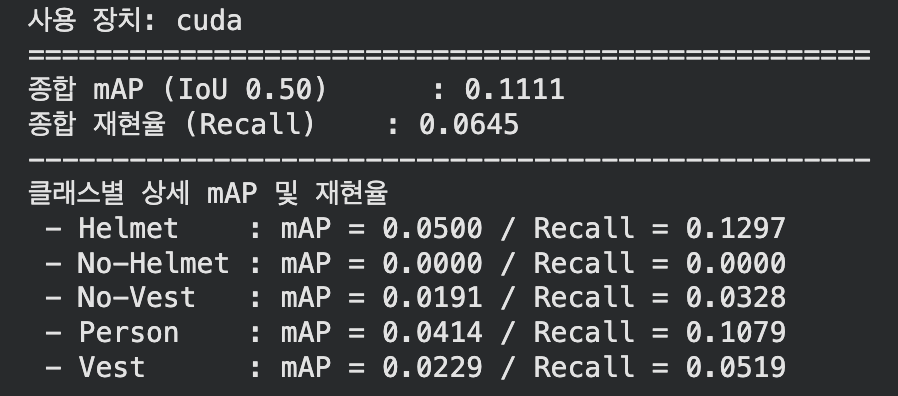

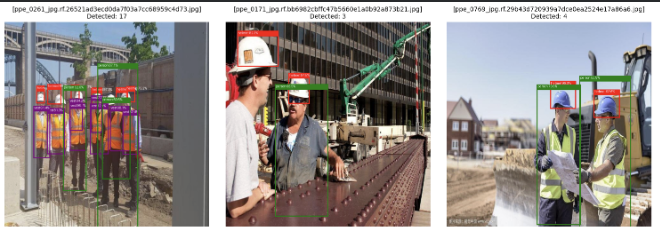

##결론
## 3. 결론
전체적으로 Faster R-CNN과 YOLOv8은 사전 학습된 Backbone을 기반으로 하여 Custom Model보다 높은 탐지 성능을 보였다. 특히 Faster R-CNN은 mAP 기준에서 안정적인 성능을 보였고, YOLOv8은 Helmet과 Person 클래스에서 높은 F1-Score를 기록하였다.

반면 Custom Model은 사전 학습된 특징 추출 능력이 부족하여 미탐지와 오탐지가 상대적으로 많이 발생하였다. 하지만 Target Encoding, Multi-anchor 기반 구조, Loss Function, 학습 과정, NMS 및 평가 과정을 직접 구현하며 객체 탐지 모델의 전체 흐름을 이해할 수 있었다는 점에서 의미가 있었다.

*결과적으로 실제 탐지 성능 측면에서는 사전 학습 모델을 활용한 Faster R-CNN과 YOLOv8이 더 적합하였고, 직접 설계한 Custom Model은 객체 탐지 구조와 학습 원리를 이해하기 위한 실험적 모델로서 의미가 있었다.*

## 4. 한계 및 개선 방향

모델마다 평가 지표와 평가 방식이 달라 세 모델을 완전히 동일한 기준으로 직접 비교하기 어렵다는 점이다. 또한 클래스별 데이터 수, 객체 크기, 클래스 간 유사성에 따라 성능 차이가 크게 나타났다.

특히 No-Helmet 클래스는 머리 부분의 작은 영역에서 판단해야 하며, Helmet 클래스와 시각적으로 혼동되기 쉬워 낮은 성능을 보인 것으로 해석된다. 향후에는 No-Helmet, No-Vest처럼 성능이 낮은 클래스의 데이터를 보강하고, 다양한 각도·거리·조명 조건의 이미지를 추가할 예정이다.

Custom Model의 경우 Data Augmentation, Hyperparameter 조정, 모델 구조 개선, 손실 함수 개선, Anchor Box 설정 조정, NMS threshold 조정 또는 Soft-NMS 적용을 통해 성능을 개선할 수 있다.
